# Volatility Surface

블랙 숄즈 방정식과 저희가 이전 세션까지 실행하던 파생상품의 가격결정은 모두 $\sigma$, 즉 기초자산의 변동성이 상수라는 것을 가정합니다. 하지만 실제 시장에서는 이 가정이 성립하지 않습니다. 이번 세션에서는 파생상품의 가격 결정을 할 때 이 현상으로 인한 오차를 정정하는 방법을 공부합니다.

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm
N = norm.cdf
from datetime import datetime
import datetime as dt
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import quad
def CallOptionBS(S, K, T, r, q, sigma):
    if T == 0.0:
        return np.maximum(S - K, 0)
    else:
        d1 = (np.log(S / K) + (r - q + sigma ** 2 / 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * np.exp(-q * T) * N(d1) - K * np.exp(-r * T) * N(d2)
def callequation(sigma,K, T, r, q, st,Q):
    return CallOptionBS(st, K, T, r, q, sigma)-Q
import warnings
warnings.filterwarnings('ignore')

## 1. 내재 변동성

이전 세션까지는 옵션의 변동성을 상수로 설정하고 가격을 계산했습니다. 실제 시장에서도 이런 가정이 성립하는지 확인하겠습니다.<br>
우선 변동성의 변화에 따른 옵션 가격의 변화를 보면 다음과 같습니다.

(0.01, 1.0)

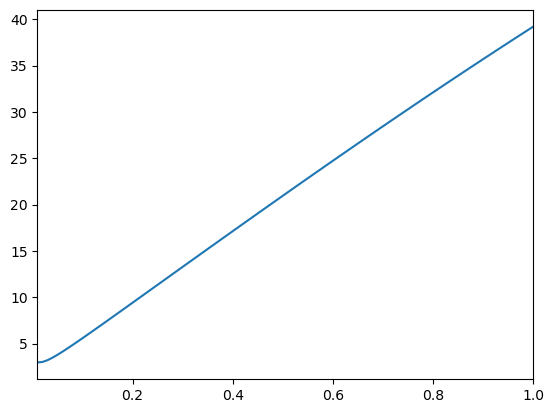

In [3]:
s0 = 100
K = 100
r = 0.03
q = 0
T = 1
CallbyVol = pd.DataFrame(columns = ["vol","price"],index = range(0,100))
for i in range(0,100):
    CallbyVol.iloc[i,0] = (i+1)/100
    CallbyVol.iloc[i,1] = CallOptionBS(s0, K, T, r, q, (i+1)/100)
plt.plot(CallbyVol["vol"],CallbyVol["price"])
plt.xlim(0.01,1.0)

이처럼 변동성이 증가함에 따라 옵션 가격은 단조적으로 증가하고, 따라서 옵션 가격과 기초자산의 현재가, 행사가, 이자율, 만기가 옵션의 가격과 함께 정해진다면 그 옵션의 변동성을 역으로 계산하는 것이 가능합니다. 그리고 이렇게 구한 변동성을 내재 변동성(Implied Volatility) 라고 합니다. 이제 실제 옵션 데이터로부터 내재 변동성을 구합니다.

In [4]:
try:
    Option = pd.read_excel("S&P500_option.xlsx",usecols=["asset","S","K","expire","price"])
except FileNotFoundError:
    Option = pd.read_excel("notebooks/S&P500_option.xlsx",usecols=["asset","S","K","expire","price"])
Option['price'] = pd.to_numeric(Option['price'], errors='coerce').fillna(0).astype(float)
Option = Option[Option["price"]!=0]
Option = Option[Option["expire"]>0.05]
Option["IV"] = 0
error = []
r = 0.05
for i in range(0,Option.shape[0]):

    try:
        K = Option.iloc[i,2]
        T = Option.iloc[i,3]
        S = Option.iloc[i,1]
        c = Option.iloc[i,4]
        Option.iloc[i,5] = scipy.optimize.fsolve(callequation,0.2,args = (K,T,r,0,S,float(c)))
        if CallOptionBS(S, K, T, r, 0, Option.iloc[i,5])!=c:
            error.append(i)
        
    except ValueError:
        error.append(i)

Option = Option[(Option["IV"]!=0.2)]


이제 같은 만기를 가진 옵션들의 내재 변동성과 행사가의 관계를 보면 다음과 같습니다

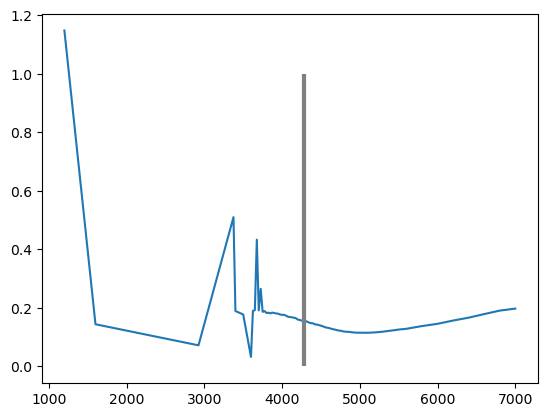

In [5]:
T = Option['expire'].unique()[25]
OptionT = Option[Option['expire']==T]
plt.plot(OptionT["K"],OptionT["IV"])
plt.vlines(S, 0, 1.0, color='gray', linestyle='solid', linewidth=3)

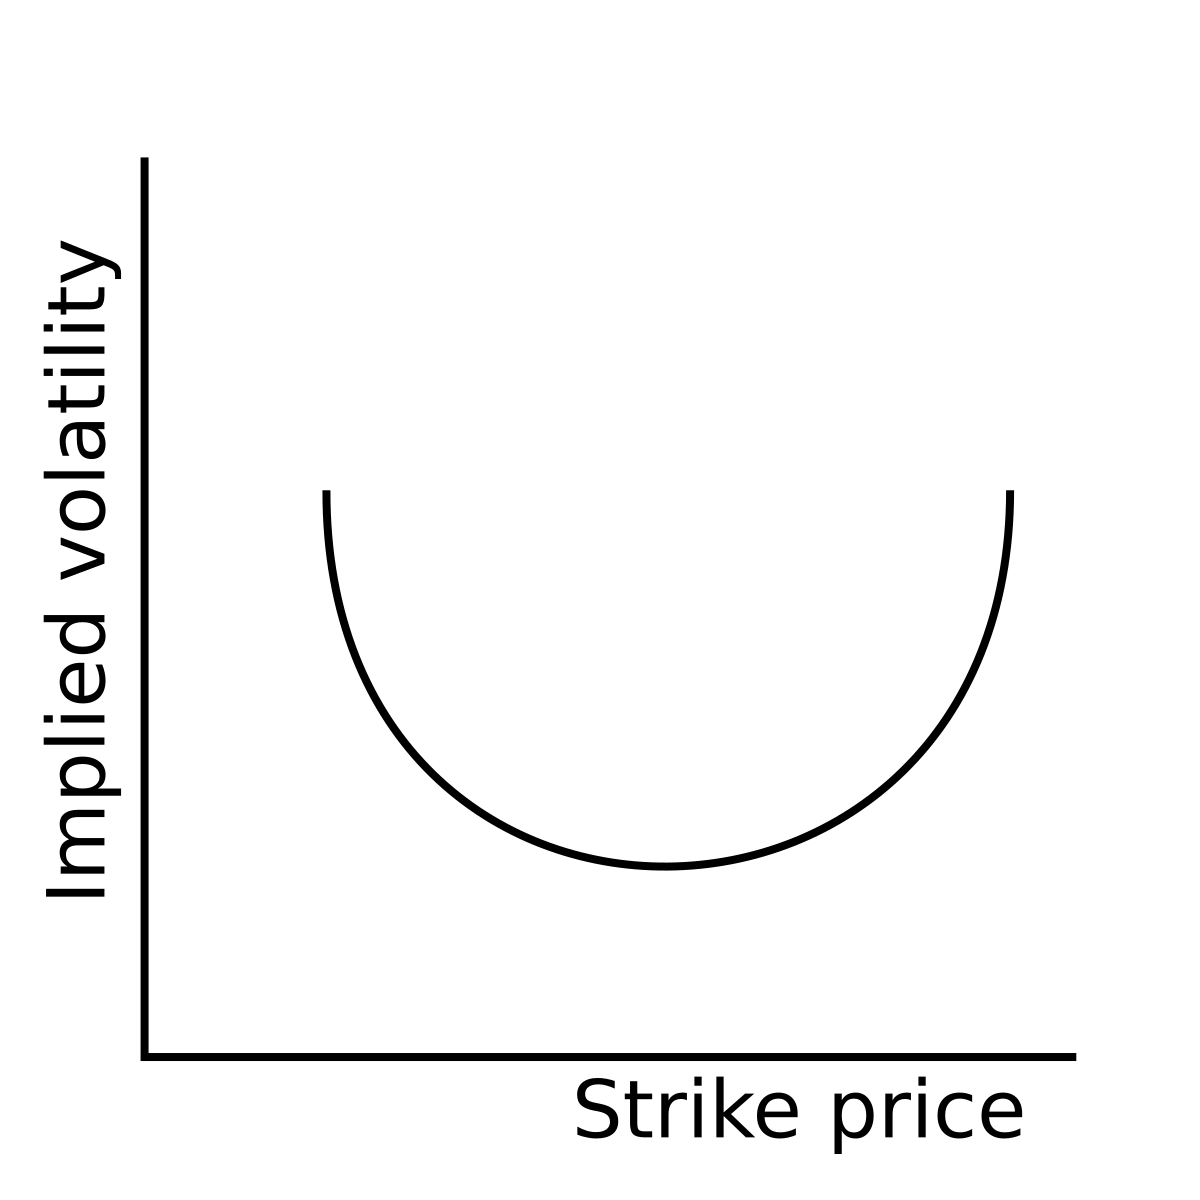

현재가 근처에서 낮은 변동성을 보이고 내가격과 외가격에서 높은 변동성을 보이는 것을 확인할 수 있습니다. 이러한 현상을 변동성 스마일이라고 합니다. 그리고 이러한 변동성을 z축으로, 행사가와 만기를 각각 x.y축으로 가지는 그래프를 내재 변동성 곡면이라고 합니다.

(0.0, 0.4)

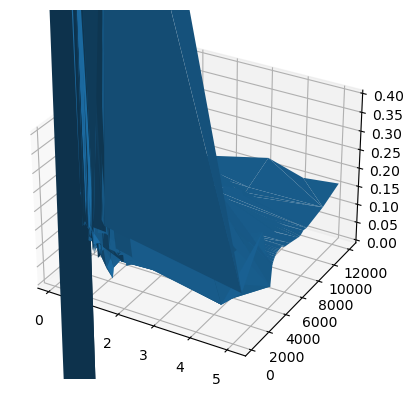

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_trisurf(Option["expire"], Option["K"], Option["IV"], linewidth=0.1, antialiased=True)
ax.set_zlim(0,0.4)

## 2. 국소 변동성 곡면에 대한 설명

이렇듯 행사가, 만기마다 각각 내재 변동성이 다르기 때문에 몬테카를로 시뮬레이션이나 유한차분법을 시행할 때 상수 변동성을 사용하는 것은 큰 오류를 낳을 수 있습니다. 이런 현상을 보정하기 위해 쓰는 방법으로 국소 변동성 곡면(Local Vol Surface)이 있습니다.<br>
내재 변동성 곡면은 (K,T)$\rightarrow \sigma$인 함수이기 때문에 이를 시뮬레이션이나 유한차분법에 이용할 수 없습니다. <br>그래서 만들어진 것이 국소 변동성 곡면입니다.<br> 국소 변동성 곡면은 (S,T)$\rightarrow \sigma$ 인 함수이므로 각 노드, path와 시점에서 S와 T가 주어지는 두 기법에 사용할 수 있습니다. 그리고 이상적인 국소 변동성 곡면을 이용하면 시장에 있는 모든 상품을 평가할 수 있습니다. <br>
예를 들어 국소 변동성 곡면을 사용해 몬테카를로 시뮬레이션의 패스를 만들고, 만기에서 수익구조만 변경해주는 것으로 내재 변동성의 변경 없이 해당 만기를 가지는 모든 콜옵션의 가격을 정확히 계산할 수 있습니다.<br>

국소 변동성 곡면을 만드는 방법은 간단합니다. 내재 변동성 곡면의 데이터나 옵션의 가격을 듀파이어 공식에 넣으면 됩니다.<br>
듀파이어 공식은 다음과 같습니다.첫 번째는 옵션의 가격을 이용한 공식입니다.
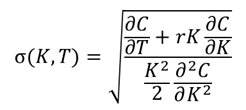<br>

두 번째는 내재 변동성 곡면을 이용한 공식입니다.



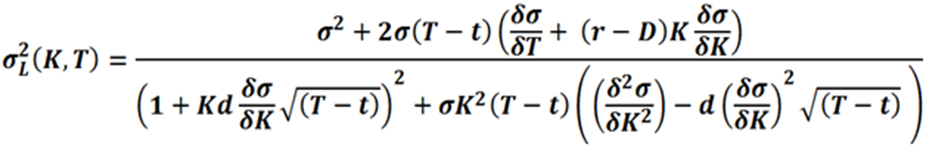<br>


이 공식에서 문제가 되는 항들은 미분항입니다. 시장에는 연속하게 만기와 행사가가 있는 것이 아니고, 주어진 몇 개의 행사가와 만기만이 있기 때문에 불연속한 데이터를 보정해 위 공식에 대입해야 합니다. 데이터를 보정하는 방법에 대해 학습하겠습니다.

# 3. 내재 변동성 곡면 산출

## 3-1. 단순 보간

첫 번째 방법은 여러 가지 보간법을 이용해 빈 데이터를 채우고, 미분값들을 계산하는 것입니다. 대표적인 보간 방법으로는 선형 보간과 스플라인 보간이 있습니다. 선형 보간은 떨어진 두 점을 직선으로 잇는 것이고, 스플라인 보간은 두 점 사이를 다항식으로 잇되, 한 점에서 만나는 만나는 두 다항식의 함숫값과 미분값이 같도록 계수를 정하는 보간법입니다. 현재 데이터는 보간하여 스마일을 그리는 데 적합하지 않으니 가상의 데이터를 만들어 예시를 보이겠습니다.

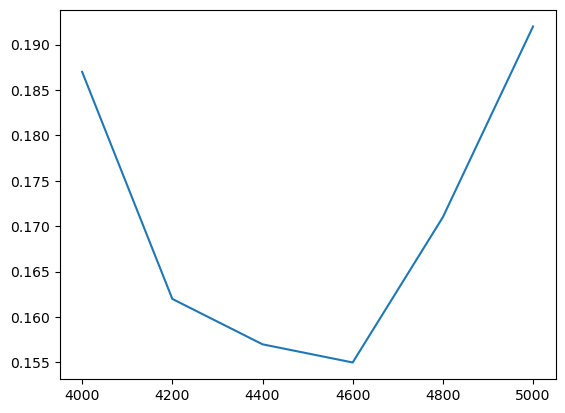

In [7]:
Strike = range(4000,5001,200)
vol = [0.187,0.162,0.157,0.155,0.171,0.192]
plt.plot(Strike,vol)

이제 이 데이터를 cubic spline 방식으로 잇되, 양 끝 점에서의 2차미분계수가 0이 되게 잇습니다.

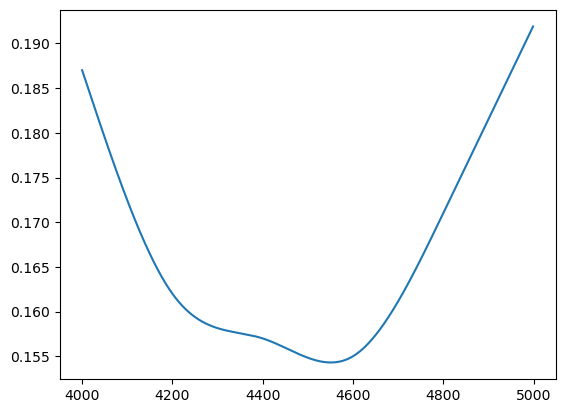

In [8]:
spline = scipy.interpolate.CubicSpline(Strike, vol, axis=0, bc_type=((2, 0.0), (2, 0.0)), extrapolate=None)
x = np.arange(4000,5000)
plt.plot(x,spline(x))

이제 만들어진 스플라인 곡선을 이용해 주어진 데이터가 아닌 행사가에서의 변동성을 구하면 됩니다.

In [9]:
spline(4350)

array(0.1575785)

## 3-2. Closed Form Solution (Heston)

두 번째 방법은, 변동성을 요구하지 않는 옵션 가격 결정 모형을 사용해 빈 곳의 가격을 채우는 것입니다. <br>
이 때 쓰는 모형이 Heston 모형입니다. Heston 모형은 기초자산의 가격이 다음과 같은 움직임을 보입니다.
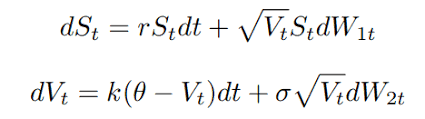<br>
이 때, $k$는 회귀 계수, $\theta$는 변동성의 평균, $\sigma$는 변동성의 변동성입니다.<br>
Heston 모형을 쓰는 이유는 이 모형은 옵션 가격의 닫힌해가 존재하기 때문입니다.<br>
(닫힌 해를 이용하여 계산한 가격 - 실제 가격)의 제곱합이 제일 작은 파라미터를 구하는 과정을 거치면 됩니다.

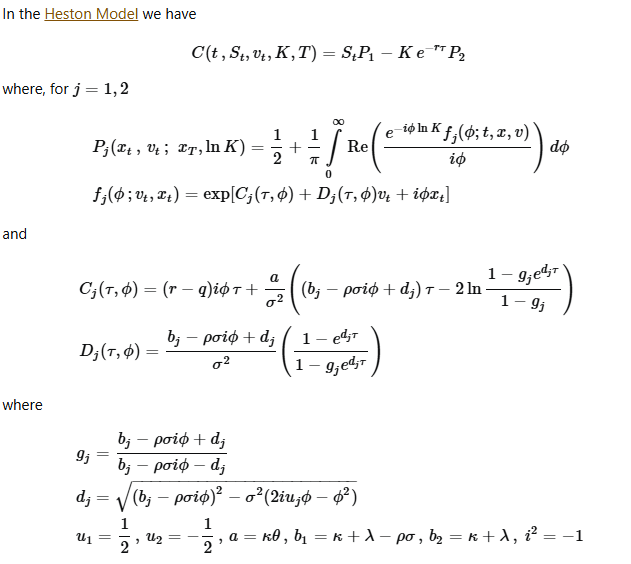<br>
이 공식을 프로그래밍으로 구현해 원하는 모든 점 (K,T)에서의 옵션 가격을 구하고, 이를 듀파이어 공식에 대입해 국소 변동성 곡면을 구하면 됩니다.

## 3-3. approximate solution (SABR)

마지막 방법은 내재 변동성을 매개변수화 시키는 것입니다. 이때 사용하는 모형이 SABR 모형입니다.<br>
SABR 모형은 기초자산이 다음과 같은 움직임을 보입니다.
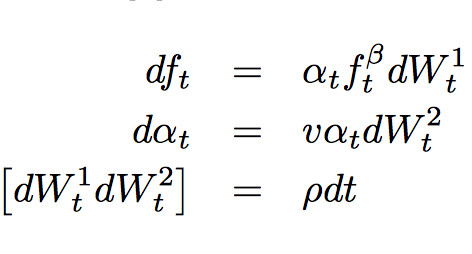<br>
SABR 모형을 사용하는 이유는 SABR 모형은 내재 변동성의 근사해가 존재하기 때문입니다.

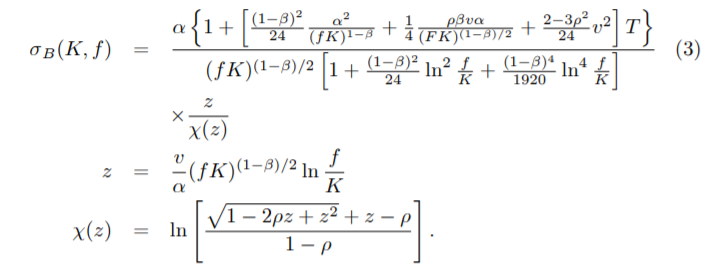<br>
이 공식으로 계산되는 변동성과 실제 변동성의 차이의 제곱합을 최소화시키는 매개변수를 구하는 과정을 calibration이라고 합니다. 이 과정을 통해 만기마다 매개변수를 구합니다.그렇게 모든 만기에 대한 변동성 스마일을 완성하고, 시간축에 대해 적절히 보간하여 내재 변동성 곡면을 완성한 뒤, 이를 듀파이어 공식에 대입해 국소 변동성 곡면을 구합니다.

In [10]:
def z(a,b,v,f,K):
    part1 = (v/a)*((f*K)**((1-b)/2))
    part2 = np.log(f/K)
    return part1*part2
def xzfunc(z,rho):
    part = np.sqrt(1-2*rho*z+z*z) + z-rho
    return np.log(part/(1-rho))
def sigma(x,K,f,T):
    a = x[0]
    b = x[1]
    rho = x[2]
    v = x[3]
    z0 = z(a,b,v,f,K)
    xz = xzfunc(z0,rho)
    c = 1-b
    part1 = (c*c*a*a)/((f*K)**c)
    part2 = rho*b*v*a/((f*K)**(0.5*c))
    part3 = (2-3*rho*rho)*v*v
    numerator = a*(1+((part1/24)+(part2/4)+(part3/24))*T)
    part4 = (f*K)**(c/2)
    part5 = c*c*(np.log(f/K))*(np.log(f/K))
    part6 = (c**4)*((np.log(f/K))**4)
    denominator = part4*(1+(part5/24) + (part6/1920))
    return (numerator/denominator) * (z0/xz)

def err(x,OptionData,r):
    N = OptionData.shape[0]
    Sqerror = 0
    for i in range(0,N):
        S = OptionData.iloc[i,1]
        K = OptionData.iloc[i,2]
        T = OptionData.iloc[i,3]
        f = S*np.exp(r*T)
        vol = OptionData.iloc[i,5]
        error = (sigma(x,K,f,T)-vol)
        Sqerror += error**2
    return Sqerror

In [11]:
counts = Option.value_counts("expire")
valid = counts[counts>40].index
NewOption = Option[Option["expire"].isin(valid)]

In [12]:
sabrparameter = pd.DataFrame(index = range(0,len(valid)),columns = ["a","b","rho","v","T","error"])
for i in range(0,len(valid)):
    x0 = [0.1,0.1,0.1,0.1]
    bnds = bnds = [(0.01,1),(0,1) ,(-0.999, 0.999), (0.01, 1)]
    OptionT = NewOption[NewOption["expire"]==valid[i]]
    result = scipy.optimize.minimize(err, x0, args = (OptionT,0.04) , tol = 1e-4, method='SLSQP', options={'maxiter': 1e6 }, bounds=bnds)
    xx = result.x
    sabrparameter.iloc[i,0] = xx[0]
    sabrparameter.iloc[i,1] = xx[1]
    sabrparameter.iloc[i,2] = xx[2]
    sabrparameter.iloc[i,3] = xx[3]
    sabrparameter.iloc[i,4] = valid[i]
    sabrparameter.iloc[i,5] = result.fun
sabrparameter = sabrparameter.sort_values(by="T")

이제 정해진 매개변수들을 T축 방향으로 spline으로 이어 주어지지 않은 만기에서의 변동성 값을 결정합니다.

In [13]:
alpha = scipy.interpolate.CubicSpline(sabrparameter["T"], sabrparameter["a"], axis=0, bc_type=((2, 0.0), (2, 0.0)), extrapolate=None)
beta = scipy.interpolate.CubicSpline(sabrparameter["T"], sabrparameter["b"], axis=0, bc_type=((2, 0.0), (2, 0.0)), extrapolate=None)
rho = scipy.interpolate.CubicSpline(sabrparameter["T"], sabrparameter["rho"], axis=0, bc_type=((2, 0.0), (2, 0.0)), extrapolate=None)
v = scipy.interpolate.CubicSpline(sabrparameter["T"], sabrparameter["v"], axis=0, bc_type=((2, 0.0), (2, 0.0)), extrapolate=None)

In [14]:
def sabrvol(alpha,beta,rho,v,S,K,r,T):
    f = S*np.exp(r*T)
    a = alpha(T)
    b = beta(T)
    ro = rho(T)
    vol = v(T)
    return sigma([a,b,ro,vol],K,f,T)

주어진 K,T에서의 변동성을 구하는 공식을 이용해 해당 점에서의 변동성, 미분값을 구하여 내재 변동성 곡면을 완성합니다.

In [57]:
ivindex = np.arange(3000,5001,100)
ivindex = np.union1d(ivindex,np.arange(3001,5002,100))
ivindex = np.union1d(ivindex,np.arange(2999,5002,100))
ivcolumn = np.arange(0.25,2.25,0.25)
ivcolumn = np.union1d(ivcolumn,np.arange(0.26,2.26,0.25))
impvol = pd.DataFrame(index = ivindex,columns = ivcolumn)
localvol = pd.DataFrame(index = np.arange(3000,5001,100),columns = np.arange(0.25,2.25,0.25))

In [72]:
S = 4284.660156
r = 0.05
for i in range(0,impvol.shape[0]):
    for j in range(0,impvol.shape[1]):
        K = impvol.index[i]
        T = impvol.columns[j]
        impvol.iloc[i,j] = sabrvol(alpha,beta,rho,v,S,K,r,T)
impvol = impvol.apply(pd.to_numeric)
impvol = impvol.interpolate(method="spline",order=3,axis=1)

## 4. 국소 변동성 곡면 계산

이제 SABR 모형을 이용해 만든 내재 변동성 곡면에서 국소 변동성 곡면을 산출합니다.

In [68]:
for i in range(0,localvol.shape[0]):
    for j in range(0,localvol.shape[1]):
        K = localvol.index[i]
        T = localvol.columns[j]
        vol = impvol.loc[K,T]
        volu = impvol.loc[K+1,T]
        vold = impvol.loc[K-1,T]
        volt = impvol.loc[K,T+0.01]
        d1 = (np.log(S/K) + (r+(vol*vol/2))*T)/(vol*np.sqrt(T))
        dK = (volu-vold)/2
        dK2 = volu+vold-2*vol
        dT = (volt-vol)/0.01
        numerator = vol*vol + 2*vol*T*(dT+r*K*dK)
        part1 = (1+K*d1*dK*np.sqrt(T))**2
        part2 = vol*K*K*T*(dK2-d1*dK*dK*np.sqrt(T))
        denominator = part1+part2
        var = numerator/denominator
        if(var<0):
            localvol.loc[K,T] = 0.01
        else:
            localvol.loc[K,T] = np.sqrt(var)

In [69]:
localvol
localvol = localvol.apply(pd.to_numeric)
localvol = localvol.interpolate(method="linear",axis=1)

In [71]:
localvol

,0.25,0.50,0.75,1.00,1.25,1.50,1.75,2.00
3000,0.645281,1.292930,2.537951,0.010000,0.010000,1.949755,0.01,0.010000
3100,0.599775,1.184334,2.425489,0.010000,0.010000,1.792100,0.01,0.010000
3200,0.556155,1.080788,2.317120,0.010000,0.341163,1.640796,0.01,0.010000
3300,0.514338,0.982073,2.212634,0.010000,0.580773,1.495458,0.01,0.010000
3400,0.474258,0.888006,2.111853,0.010000,0.712181,1.355756,0.01,0.010000
3500,0.435872,0.798445,2.014627,0.010000,0.010000,1.221420,0.01,0.010000
3600,0.399161,0.713279,1.920834,0.010000,0.010000,1.092256,0.01,0.010000
3700,0.364134,0.632432,1.830382,0.010000,0.010000,0.968165,0.01,0.010000
3800,0.330839,0.555857,1.743207,0.010000,0.010000,0.849187,0.01,0.010000
3900,0.299369,0.483525,1.659276,0.010000,0.010000,0.735580,0.01,0.010000


이처럼 국소 변동성 곡면은 이상치가 나오는 것이 대다수이기에 현업에서는 이상치를 없애고 적당히 smoothing을 해서 사용하고 있습니다.

## 5. 국소 변동성 곡면 사용

만약 사용하기 적합한 국소 변동성 곡면이 도출된다면 해당 국소 변동성 곡면을 몬테카를로 시뮬레이션과 유한차분법에 이용할 수 있습니다.<br>
이번 챕터에서는 국소 변동성 곡면을 이용하는 방법을 설명합니다.

기본적으로 국소 변동성 곡면은 격자점의 집합으로 주어지게 되고, 따라서 격자점 사이의 국소 변동성을 구하기 위해서 선형 보간을 이용합니다.<br>
bilinear interpolation 방법을 이용하여 변동성을 구하고자 하는 점 (S,T) 주변의 네 격자점의 변동성 값을 이용합니다.

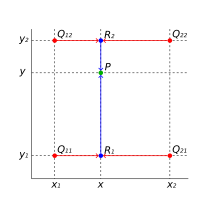

In [84]:
def locvol_linear(S,T,LV):
    SLpos = np.where(LV.index<=S)
    SUpos= np.where(LV.index>S)
    TLpos= np.where(LV.columns<=T)
    TUpos= np.where(LV.columns>T)
    SL = LV.index[SLpos[0][-1]]
    SU = LV.index[SUpos[0][0]]
    TL = LV.columns[TLpos[0][-1]]
    TU = LV.columns[TUpos[0][0]]
    VLL = LV.loc[SL,TL]
    VLU = LV.loc[SL,TU]
    VUL = LV.loc[SU,TL]
    VUU = LV.loc[SU,TU]
    t1 = (S-SL)/(SU-SL)
    t2 = (T-TL)/(TU-TL)
    VL = (VLL*(1-t2)+VLU*t2)
    VU = (VUL*(1-t2)+VUU*t2)
    return VL*(1-t1)+VU*t1

다음과 같은 간단한 국소 변동성 곡면을 설정합니다.

In [136]:
EXLV = pd.DataFrame(index = [2000,3000,4000],columns = [0,0.5,1.1])
EXLV.iloc[0,0] = 0.2
EXLV.iloc[1,0] = 0.1
EXLV.iloc[2,0] = 0.2
EXLV.iloc[0,1] = 0.18
EXLV.iloc[1,1] = 0.08
EXLV.iloc[2,1] = 0.18
EXLV.iloc[0,2] = 0.16
EXLV.iloc[1,2] = 0.06
EXLV.iloc[2,2] = 0.16

몬테카를로 시뮬레이션이나 유한차분법을 실시할 때, 변동성에 해당하는 부분을 국소 변동성으로 바꾸면 됩니다.

In [137]:
s0 = 3000
Normal = np.random.normal(size=(20, 10))
path = np.zeros((21,10))
path[0] = s0
dt = 1/20
sigmaarray = np.zeros([10,1])
for i in range(0,20):
    for j in range(0,10):
        S = path[i][j]
        T = (i+1)*dt
        sigmaarray[j] = locvol_linear(S,T,EXLV)
    norm = np.zeros([1,10])
    norm+=Normal[i].T
    logds = r*dt + norm * sigmaarray.T*np.sqrt(dt)
    path[i+1] = path[i]*(1+logds)

In [139]:
path[-1]

array([3219.1913893 , 2749.0283195 , 3195.91039662, 2720.29414108,
       3083.53521356, 3048.25824472, 3145.98447556, 3230.76324212,
       3380.92207919, 3453.53455704])

## 6. Sticky Strike, Sticky Moneyness

이렇게 국소 변동성 곡면을 이용하면 가격을 구할 수 있고, 민감도 또한 구할 수 있습니다.<br>
그런데 민감도를 구할 때, 국소 변동성을 사용하는 방식은 한 가지가 아닙니다.<br>
다음과 같은 간단한 국소 변동성 곡면을 가정하고 각 방법을 알아보겠습니다.<br>
이 때, 현재 주가는 1000이라고 가정합니다.

In [144]:
EXLV2 = pd.DataFrame(index = [900,1000,1100], columns = [0.1])
EXLV2.iloc[0,0] = 0.2
EXLV2.iloc[1,0] = 0.1
EXLV2.iloc[2,0] = 0.2
EXLV2

,0.1
900,0.2
1000,0.1
1100,0.2


### 6-1. Sticky Strike

Sticky Strike는 내재 변동성 곡면이 K축에 고정되어 있다고 생각하는 것입니다. 따라서 위와 같이 국소변동성이 주어지고, 델타를 구하기 위해 <br>
S0 = 999 로 바꾸어도 위 변동성 곡면을 그대로 사용하여 $\sigma = 0.99 \times 0.2 + 0.01 \times 0.1 = 0.101$ 로 시작하면 됩니다.

### 6-2. Sticky Moneyness(delta)

Sticky Moneyness는 내재 변동성 곡면이 K축이 아닌 moneyness, 즉 K/S에 고정되어 있다고 가정하는 것입니다. 즉, 델타를 구하기 위해 S0 = 999로 바꾼다면, 국소 변동성 곡면의 주가 축에 0.999를 곱하고, 국소 변동성 곡면은 다음과 같이 변경됩니다.

In [145]:
EXLV3 = pd.DataFrame(index = [900*0.999,1000*0.999,1100*0.999], columns = [0.1])
EXLV3.iloc[0,0] = 0.2
EXLV3.iloc[1,0] = 0.1
EXLV3.iloc[2,0] = 0.2
EXLV3

,0.1
899.1,0.2
999.0,0.1
1098.9,0.2


그리고 S0 = 999이므로 $\sigma = 0.1$로 시작하면 됩니다.